In [ ]:
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import(
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/proyecto-auto-mpg'
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Drive montado y entorno listo")

Mounted at /content/drive
Drive montado y entorno listo


* Cargamos los splits ya preparados por el notebook de EDA: train_raw y test_raw: sin escalar.

In [ ]:
train = pd.read_csv(f'{PROJECT}/data/train_raw.csv')
test  = pd.read_csv(f'{PROJECT}/data/test_raw.csv')

X_train = train.drop('mpg', axis=1)
y_train = train['mpg']

X_test  = test.drop('mpg', axis=1)
y_test  = test['mpg']

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Columnas: {list(X_train.columns)}")

Train: (318, 8) | Test: (80, 8)
Columnas: ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* Los modelos de árboles (AdaBoost, XGBoost) no necesitan escalado porque no calculan distancias ni penalizaciones, tal que, solo hacen divisiones binarias sobre los valores. Usar los datos sin escalar además facilita la interpretación de las importancias de variables en sus unidades originales.

+ **AdaBoost**

Queremos aproximar las millas por galón según características mecánicas de los autos.
+ queremos hacer que:

$$mpg = f(x_1, x_1, x_3, ... , x_n )$$

Definimos nuestro arbol base

In [ ]:
arbol_base = DecisionTreeRegressor(max_depth=5, random_state = 42)

+ Definimos el modelo ADA

In [ ]:
ADA = AdaBoostRegressor(
    estimator = arbol_base,
    n_estimators= 400,
    learning_rate = 0.07,
    random_state=42
)

+ Entrenamiento

In [ ]:
Y_train_log = np.log1p(y_train)

In [ ]:
ADA.fit(X_train, Y_train_log)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
                  learning_rate=0.07, n_estimators=400, random_state=42)

+ predicciones log

In [ ]:
y_pred_log = ADA.predict(X_test)

+ Predicciones

In [ ]:
y_pred_ada = np.expm1(y_pred_log)
#print(y_pred_ada)

+ Evaluaremos el modelo mediante **RME**, **LMSE** Y **MAE**

In [ ]:
mse_ADA =mean_squared_error(
    y_test,
    y_pred_ada
)

rmse_ADA = np.sqrt(mse_ADA)

mae_ADA = mean_absolute_error(
    y_test,
    y_pred_ada
)

r2_ADA = r2_score(y_test, y_pred_ada)

print(f'RMSE : {rmse_ADA}')
#print(f'MSE: {mse_ADA}')
print(f'MAE: {mae_ADA}')
print(f'R^2: {r2_ADA}')

RMSE : 2.4324171144388878
MAE: 1.7400086656712446
R^2: 0.8899564002014695


+ Pequeña visualización

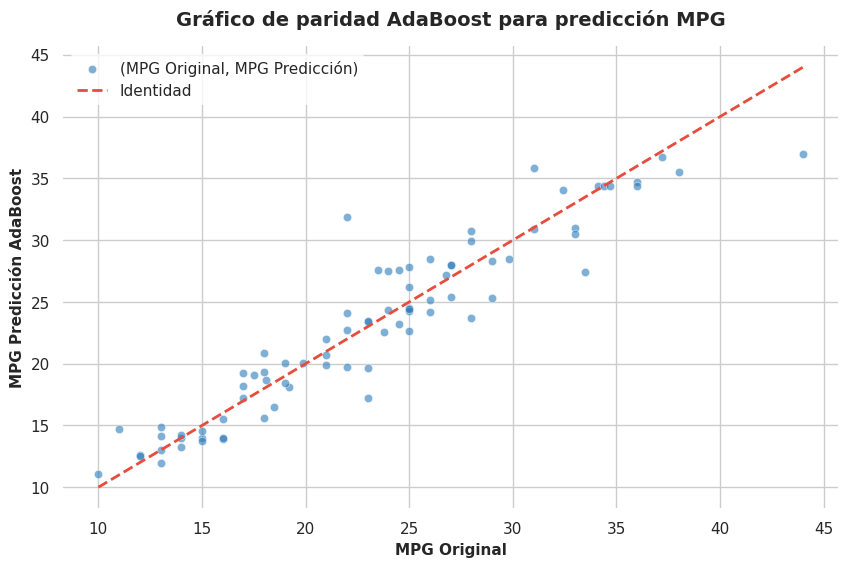

In [ ]:
sns.set_theme(style='whitegrid', context = "notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            y_pred_ada,
            color = '#2b7bba',
            alpha = 0.6,
            edgecolors = 'w',
            linewidths = 0.5,
            label = '(MPG Original, MPG Predicción)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
       color = '#e74c3c',
       linestyle ='--',
       linewidth = 2,
       label = 'Identidad'

)
plt.title('Gráfico de paridad AdaBoost para predicción MPG', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize = 11, fontweight = 'semibold')
plt.ylabel('MPG Predicción AdaBoost', fontsize =11, fontweight = 'semibold')
plt.legend(frameon = True, facecolor='white', edgecolor='none')
sns.despine(left = True, bottom = True)
plt.savefig(f'{PROJECT}/figures/prediccion_ada_base.png',
            bbox_inches='tight')
plt.show()

+ **XGBOOST**

+ Definimos el modelo junto con sus hiperparámetros

In [ ]:

XGB = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,

    min_child_weight = 5, #evita crear hojas con pocas observaciones
    gamma = 0.1, #exige una reducción minima del error al crear una nueva división

    #early_stopping_rounds = 5, #evita sobreajuste

    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,

    reg_alpha = 0.1,
    reg_lambda = 1.0,

    random_state = 42
                    )

+ Entrenamiento XGB "empírico".

In [ ]:
XGB.fit(X_train, Y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

+ Prediccion

+ transformacion logarítimica

In [ ]:
Y_pred_xgb_log = XGB.predict(X_test)
#print(Y_pred_xgb)

#aplicamos exponencial
Y_pred_xgb = np.expm1(Y_pred_xgb_log)

+ Evaluamos el modelo mediante **MSE**, **RMSE** y **MAE**

In [ ]:
mse_xgb = mean_squared_error(
    y_test,
    Y_pred_xgb
)

rmse_xgb = np.sqrt(mse_xgb)

mae_xgb = mean_absolute_error(
    y_test, Y_pred_xgb
)

r2_xgb = r2_score(y_test, Y_pred_xgb)

#print(f'MSE:{mse_xgb}')
print(f'RMSE: {rmse_xgb}')
print(f'MAE: {mae_xgb}')
print(f'R^2: {r2_xgb}')

RMSE: 2.2910853740784427
MAE: 1.7852619647979737
R^2: 0.9023727100917632


+ Visualización

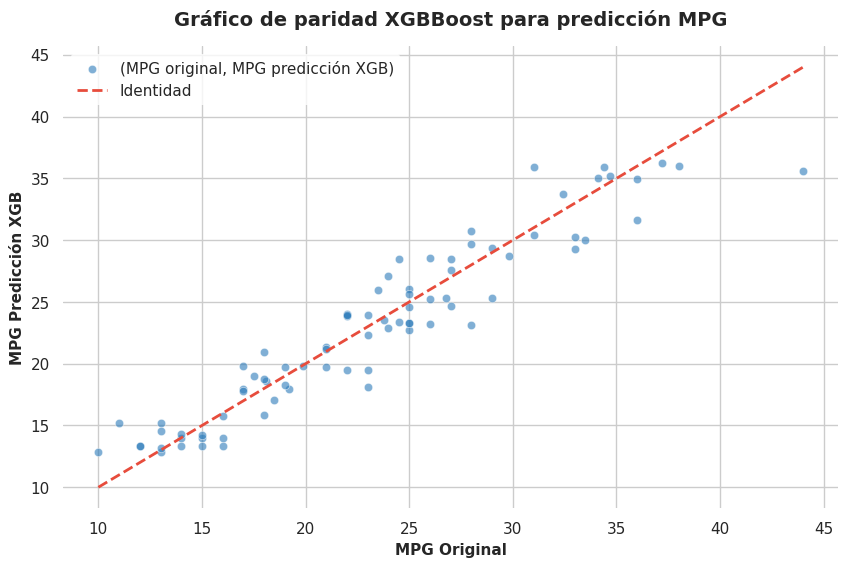

In [ ]:
sns.set_theme(style ='whitegrid', context = "notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            Y_pred_xgb,
            color = '#2b7bba',
            alpha = 0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(MPG original, MPG predicción XGB)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = '#e74c3c',
    linestyle = '--',
    linewidth = 2,
    label = 'Identidad'
)
plt.title('Gráfico de paridad XGBBoost para predicción MPG', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize = 11, fontweight='semibold')
plt.ylabel('MPG Predicción XGB', fontsize =11, fontweight='semibold')
plt.legend(frameon = True, facecolor='white', edgecolor='none')
sns.despine(left = True, bottom = True)
plt.savefig(f'{PROJECT}/figures/prediccion_xgb_base.png',
            bbox_inches='tight')
plt.show()

------------------------------------------------
------------------------------------------------------------------------------------------------

+ **GRID SEARCH PARA XGBOOST**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [ ]:
cross_fold = KFold(n_splits = 5, shuffle=True, random_state=42)

+ Buscaremos hiperparámetros automáticamente  

In [ ]:
from sklearn.model_selection import GridSearchCV

+ Definimos la rejilla de parámetros

In [ ]:
params_XGB = {
    'max_depth' : [3,4,5],
    'learning_rate' : [0.01, 0.05, 0.07],
    'n_estimators' : [200, 300, 400],
    'reg_alpha' : [0.01, 0.03, 0.04],
    'reg_lambda' : [1.0, 3.0, 4.0],
    'gamma' : [0.1, 0.2,0.3],
    #'min_child_weight' : [3, 5, 6]
}

#creamos el modelo

model_XGB = XGBRegressor(
    subsample =0.8,
    colsample_bytree = 0.8,
    random_state=42
)

#ejecutamos el modelo

grid_XGB = GridSearchCV(
    estimator = model_XGB,
    param_grid = params_XGB,
    cv = 5,
    scoring='r2',
    n_jobs = -1
)

#entrenamos

grid_XGB.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None, colsample_bytree=0.8,
                                    device=None, early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0.1, 0.2, 0.3],
                         'learning_rate': [0.01, 0.05, 0.07],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [200, 300, 400],
                         'reg_alpha': [0.01, 0.03, 0.04],
                         'reg_lambda': [1.0, 3.0, 4.0]},
             scoring='r2')

+ vemos los mejores parámtros

In [ ]:
print(grid_XGB.best_params_)

{'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.01, 'reg_lambda': 4.0}


+ entrenamos el mejor modelo

In [ ]:
best_xgb_grid = grid_XGB.best_estimator_

+ veamos sus parámetros

In [ ]:
print(best_xgb_grid)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


+ Vamos a hacer predicciones y evaluar las métricas

In [ ]:
y_pred_XGB_grid = best_xgb_grid.predict(X_test)

mse_grid = mean_squared_error(y_test, y_pred_XGB_grid)
rmse_grid = mse_grid**0.5
mae_grid = mean_absolute_error(y_test, y_pred_XGB_grid)
r2_grid = r2_score(y_test, y_pred_XGB_grid)

print(f'RMSE: {rmse_grid}')
#print(f'MSE: {mse_grid}')
print(f'MAE: {mae_grid}')
print(f'R^2: {r2_grid}')

RMSE: 2.321099160340311
MAE: 1.7433005905151369
R^2: 0.8997980722477578


+ Visualización de XGB mediante grid search

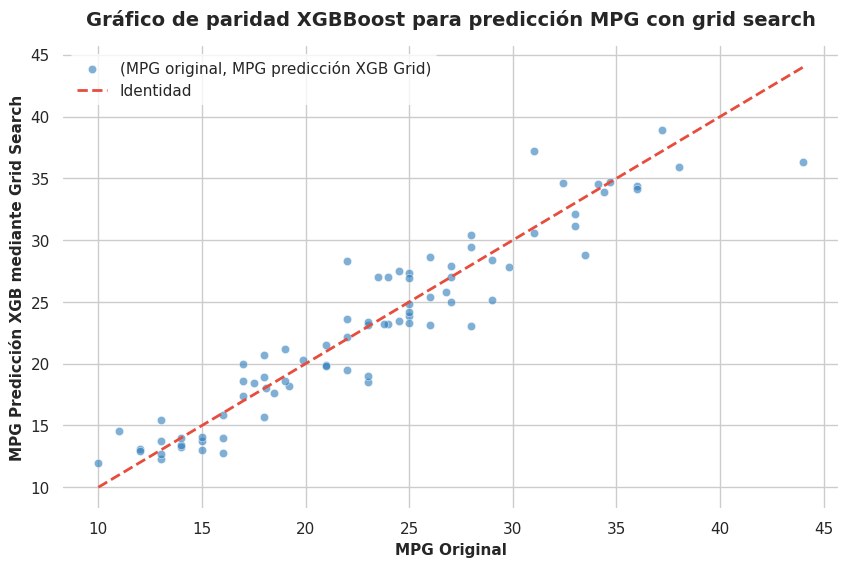

In [ ]:
sns.set_theme(style='whitegrid', context="notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            y_pred_XGB_grid,
            color='#2b7bba',
            alpha=0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(MPG original, MPG predicción XGB Grid)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Identidad'
)
plt.title('Gráfico de paridad XGBBoost para predicción MPG con grid search', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize =11, fontweight='semibold')
plt.ylabel('MPG Predicción XGB mediante Grid Search', fontsize =11, fontweight='semibold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.savefig(f'{PROJECT}/figures/Prediccion_XGB_GS',
            bbox_inches='tight')
plt.show()

------------------------------------------------
------------------------------------------------
------------------------------------------------
**GRID SEARCH PARA ADABOOST**

+ La idea al hacer gridsearch con adaboost es la misma que para xgboost

+ Ya habiamos definido un arbol base y un modelo __ADA__

Definimos la rejilla de parámetros

In [ ]:
param_grid_ADA = {
    'estimator__max_depth' : [3,4,5],
    'n_estimators' : [200, 300, 400],
    'learning_rate' : [0.02, 0.04, 0.05],
    'loss' : ['linear', 'square']
}

+ Ya habíamos definido el cross fold y el modelo ADA

In [ ]:
grid_ADA = GridSearchCV(
    estimator = ADA,
    param_grid = param_grid_ADA,
    cv = cross_fold,
    scoring = 'r2',
    n_jobs = -1
)

+ Entrenamos el modelo

In [ ]:
grid_ADA.fit(X_train, y_train) #tarda aprox 2 mins en correr

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5,
                                                                         random_state=42),
                                         learning_rate=0.07, n_estimators=400,
                                         random_state=42),
             n_jobs=-1,
             param_grid={'estimator__max_depth': [3, 4, 5],
                         'learning_rate': [0.02, 0.04, 0.05],
                         'loss': ['linear', 'square'],
                         'n_estimators': [200, 300, 400]},
             scoring='r2')

In [ ]:
print(grid_ADA.best_params_)

best_ADA_grid = grid_ADA.best_estimator_

{'estimator__max_depth': 5, 'learning_rate': 0.05, 'loss': 'linear', 'n_estimators': 300}


+ Recuperamos el modelo con mejores parámetros segun el grid search

In [ ]:
#prediccion
pred_ADA_grid = best_ADA_grid.predict(X_test)

+ Calculo de las métricas

In [ ]:
#y_pred_ADA_grid = best_ADA_grid.predict(X_test)

mse_grid_ada = mean_squared_error(y_test, pred_ADA_grid)
rmse_grid_ada = mse_grid_ada**0.5
mae_grid_ada = mean_absolute_error(y_test, pred_ADA_grid)
r2_grid_ada = r2_score(y_test, pred_ADA_grid)

print(f'RMSE: {rmse_grid_ada}')
#print(f'MSE: {mse_grid_ada}')
print(f'MAE: {mae_grid_ada}')
print(f'R^2: {r2_grid_ada}')

RMSE: 2.2466583568591294
MAE: 1.6681324069634509
R^2: 0.9061222312579496


+ Visualización de AdaBoost mediante Cross Validation

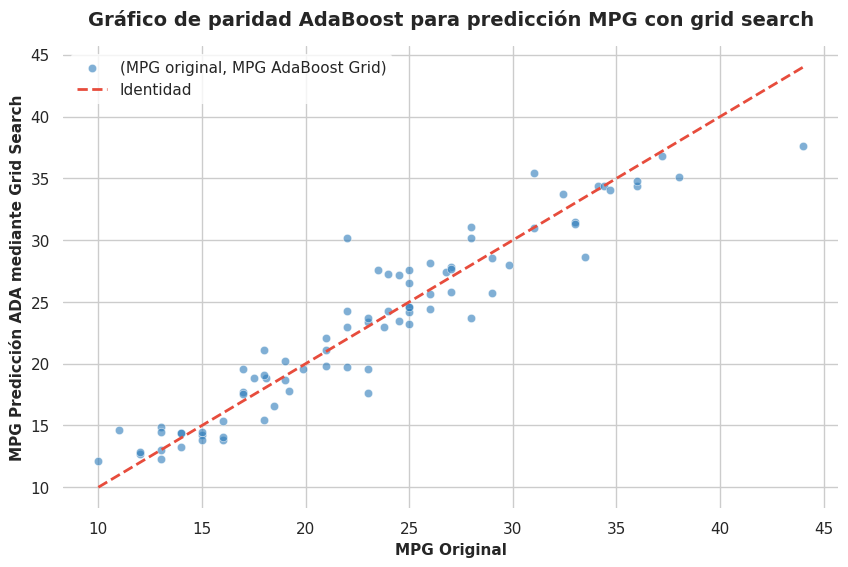

In [ ]:
sns.set_theme(style='whitegrid', context="notebook")
plt.figure(figsize=(10,6))
plt.scatter(y_test,
            pred_ADA_grid,
            color='#2b7bba',
            alpha=0.6,
            edgecolors='w',
            linewidths=0.5,
            label='(MPG original, MPG AdaBoost Grid)')
plt.plot(
       [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Identidad'
)
plt.title('Gráfico de paridad AdaBoost para predicción MPG con grid search', fontsize =14, fontweight ='bold',pad=15)
plt.xlabel('MPG Original', fontsize=11, fontweight='semibold')
plt.ylabel('MPG Predicción ADA mediante Grid Search', fontsize=11, fontweight='semibold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
sns.despine(left=True, bottom=True)
plt.savefig(f'{PROJECT}/figures/Prediccion_ADA',
            bbox_inches='tight')
plt.show()

+ Importancia de Features según cada modelo


In [ ]:
# creamos un DF con las importancias de AdaBoost

dfAda_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_ADA_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)

#creamos un df con las importancias de XGBoost

dfXGB_features_imp = pd.DataFrame({
    'feature' : X_train.columns,
    'importance' : best_xgb_grid.feature_importances_
}).sort_values(by = 'importance', ascending = False)


+ Graficación de importance features

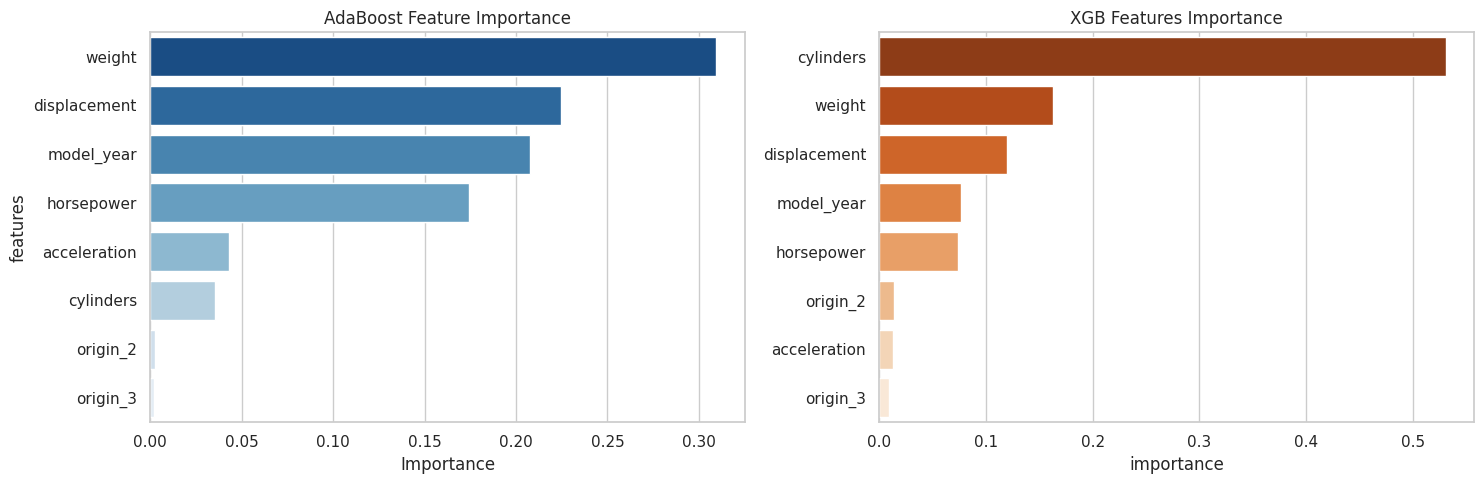

In [ ]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

#graf para Ada
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')

#graf para XGB
sns.barplot(x = 'importance', y = 'feature', hue= 'feature', data = dfXGB_features_imp, ax=axes[1], palette = 'Oranges_r')
axes[1].set_title('XGB Features Importance')
axes[1].set_xlabel('importance')
axes[1].set_ylabel('')

#graf para ada por cross validation
sns.barplot(x = 'importance', y = 'feature', hue = 'feature', data = dfAda_features_imp, ax = axes[0], palette='Blues_r')
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('features')


#plot
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/importancias_ADA_XGB.png',
            bbox_inches='tight')
plt.show()

Las importancias de las features evaluadas por AdaBoost y por XGB son diferentes. Sin embargo, las variables con mayor importancia, elegidas por cada modelo, parecen estar dentro de la lógica del problema, pues un mayor peso requerirá mayor consumo de combustible, así como un mayor cilindraje, requerirá un mayor consumo.

+ La diferencia en la evaluación del nivel de importancia es normal:

+ *AdaBoost* calcula la importancia usando el coeficiente ´gini importance´ o el ´mean decrece in impurity (MDI)´. Mide qué tanto ayudan las características a purificar los nodos de los árboles de decisión que se van creando.

+ *XGBoost* utiliza el coeficiente ´gain´ y mide la meora relatica en la precisión que aporta cada caracterísitica al ser introducida en las ramas del árbol.


+ Hagamos una comparación de los resultados obtenidos con cada modelo:


In [ ]:
evaluacion = pd.DataFrame({
    "modelo" : ["AdaBoost", "XGBoost", "AdaBoost GS", "XGB GS"],
    #"MSE" : [mse_ADA, mse_xgb, mse_grid_ada, mse_grid],
    "RMSE" : [rmse_ADA, rmse_xgb, rmse_grid_ada, rmse_grid],
    "MAE" : [mae_ADA, mae_xgb, mae_grid_ada, mae_grid],
    "R^2" : [r2_ADA, r2_xgb, r2_grid_ada, r2_grid]
})
print(evaluacion)

        modelo      RMSE       MAE       R^2
0     AdaBoost  2.432417  1.740009  0.889956
1      XGBoost  2.291085  1.785262  0.902373
2  AdaBoost GS  2.246658  1.668132  0.906122
3       XGB GS  2.321099  1.743301  0.899798


+ Al implementar hiperparámetros ajustados según el tipo de problema tratado, encontramos una mejoría en XGB respecto a ADA. Los parámetros clave incorporados en esta mejoría fueron *reg_alpha=0.1*, *reg_lambda = 1.0*, *gamma=1.0* y *min_child_weight = 5*. Al incorporar estos hiperparámetros en XGB, los coeficientes de evaluación mejoraron y son similares a los obtenidos con ADA.

* Por ultimo, guardamos las metricas finales en un csv

In [ ]:
# Guardar métricas en Drive para comparativa final
evaluacion.to_csv(f'{PROJECT}/data/metricas_boosting.csv', index=False)

# Verificar guardado
import os
print("Archivos en data/:")
for a in sorted(os.listdir(f'{PROJECT}/data')):
    if not a.startswith('.'):
        print(f"  - {a}")

Archivos en data/:
  - auto_mpg_clean.csv
  - auto_mpg_clean.gsheet
  - metricas_boosting.csv
  - metricas_rf.csv
  - scaler.pkl
  - test_raw.csv
  - test_scaled.csv
  - train_raw.csv
  - train_scaled.csv


**errores AdaBoost**

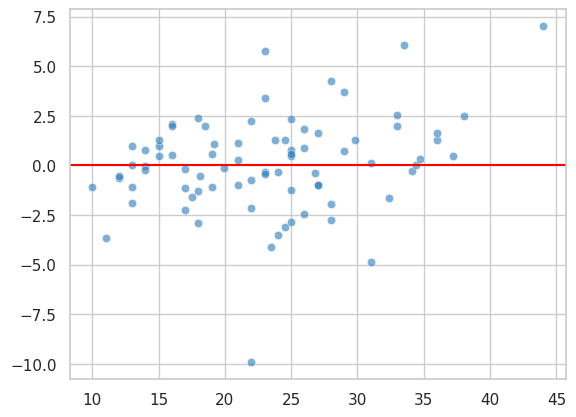

In [ ]:
errores_ada = y_test - y_pred_ada
plt.scatter(y_test, errores_ada, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

**errores con GridSearch AdaBoost**

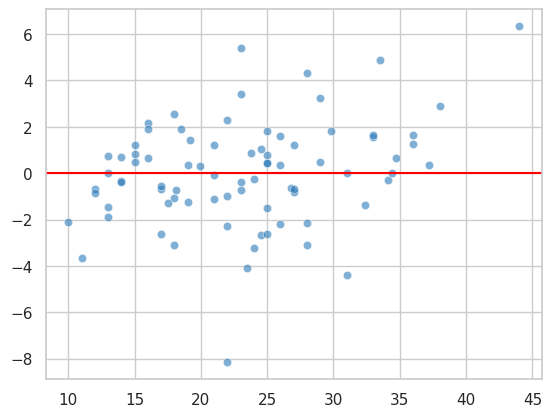

In [ ]:
errores_ada_grid = y_test - pred_ADA_grid
plt.scatter(y_test, errores_ada_grid, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

**Errores con XGBoost**

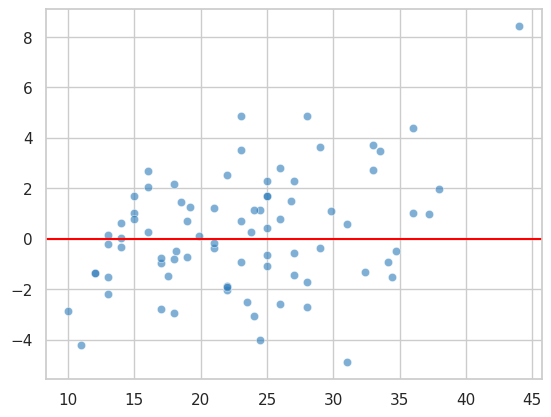

In [ ]:
errores_xgb = y_test - Y_pred_xgb
plt.scatter(y_test, errores_xgb, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')

**Errores Grid Search con XGB**

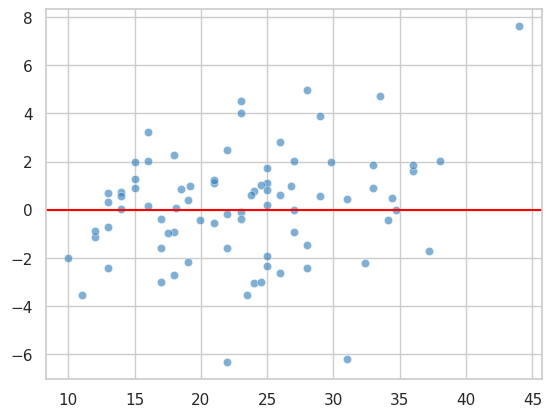

In [ ]:
errores_xgb_grid = y_test - y_pred_XGB_grid
plt.scatter(y_test, errores_xgb_grid, color = '#2b7bba', alpha = 0.6, edgecolors = 'w', linewidths = 0.5)
plt.axhline(0, color='red')